MILESTONE 2: ANTIFRAGILE ERROR CORRECTION & THE DARK SECTOR

[1/3] Running Base-8 (No Redundancy) with Noise Injection...
[2/3] Running Base-10 (With Purple Redundancy) with Noise Injection...
[3/3] Generating Visual Proof...

✓ Saved: milestone2_antifragile_error_correction.png


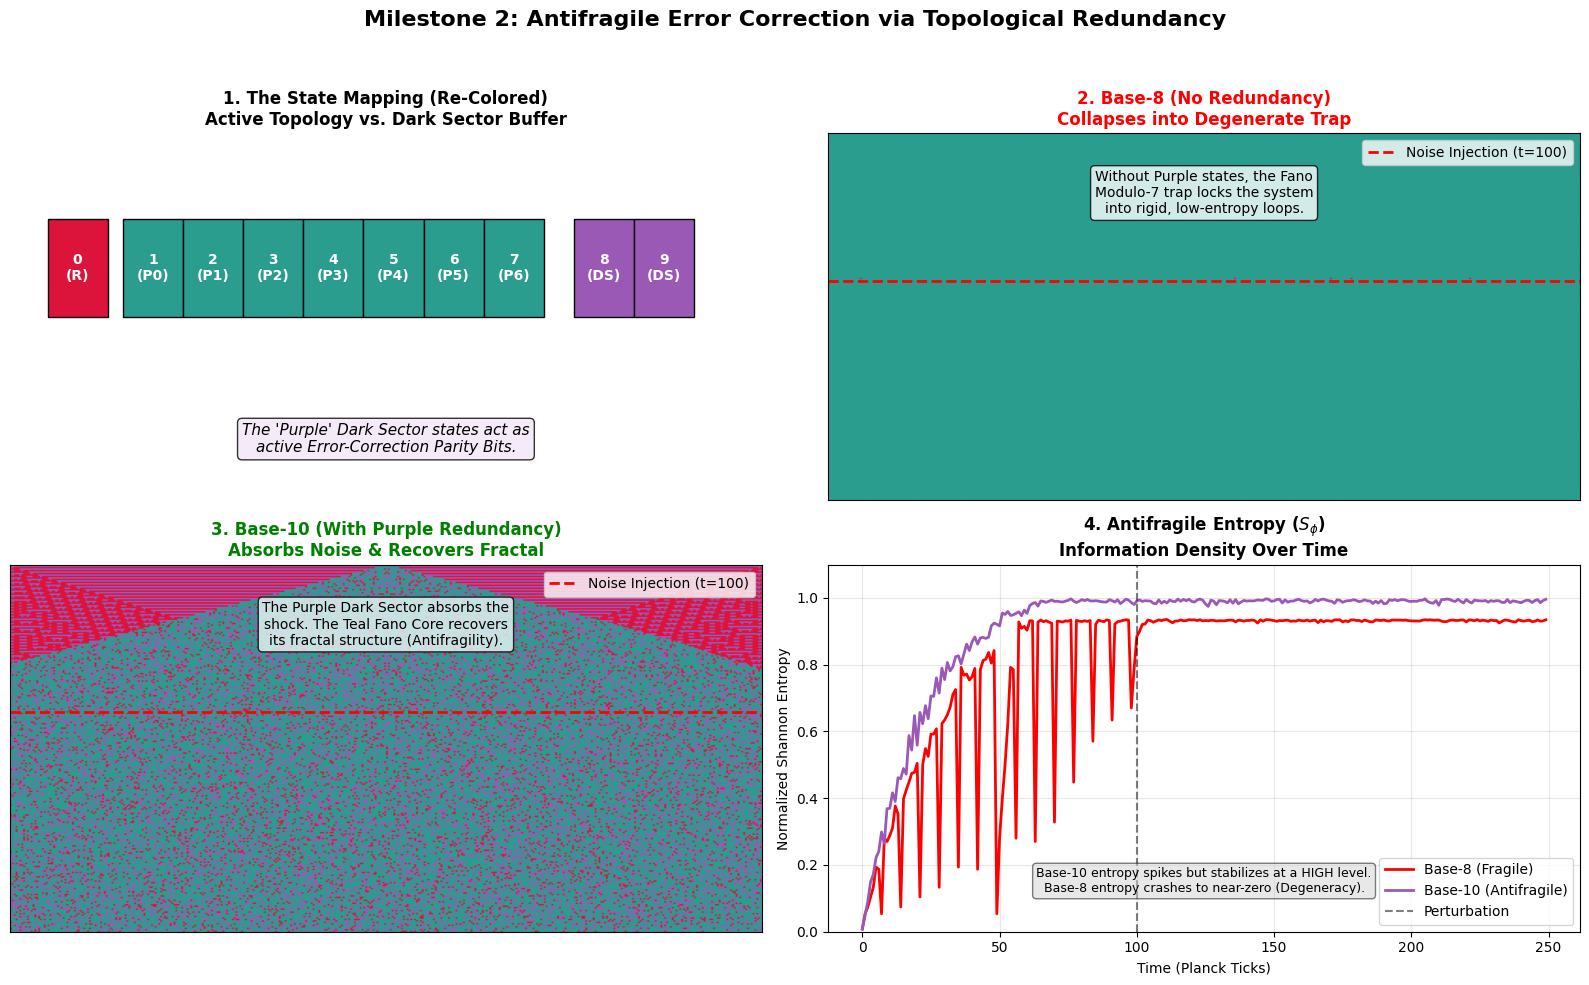


CONCLUSION
The 'Purple' Dark Sector states are not empty packaging.
They are the topological error-correction mechanism that allows
the universe to decompress its fractal geometry without corrupting,
validating the concept of Antifragile Entropy (Pellis, 2025).


In [2]:
"""
milestone2_antifragile_error_correction.py
==========================================
Visual proof of Milestone 2: Topological Redundancy as Error Correction.
Demonstrates how the "Purple" Dark Sector states absorb quantum noise,
preventing the fractal from collapsing (Antifragility).

Author: Néstor E. Ramos
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

print("=" * 70)
print("MILESTONE 2: ANTIFRAGILE ERROR CORRECTION & THE DARK SECTOR")
print("=" * 70)

# =============================================================================
# 1. THE GOLDEN-FANO AUTOMATON (With Noise Injection)
# =============================================================================

def run_fano_ca_with_noise(base, steps=250, width=400, noise_step=100, noise_level=0.10):
    """Runs the CA and injects quantum noise at a specific time step."""
    grid = np.zeros((steps, width), dtype=int)
    grid[0, width // 2] = 1 # Seed

    W = np.array([1, 2, 3, 5, 3, 2, 1])
    reserved_state = base - 1
    active_modulus = base - 1

    for t in range(1, steps):
        # INJECT NOISE
        if t == noise_step:
            mask = np.random.rand(width) < noise_level
            # FIX: Generate random states ONLY for the masked elements
            random_states = np.random.randint(0, base, size=mask.sum())
            grid[t-1, mask] = random_states

        padded_row = np.pad(grid[t-1], (3, 3), mode='constant', constant_values=0)
        weighted_sum = np.zeros(width, dtype=int)
        for i in range(7):
            weighted_sum += W[i] * padded_row[i : i + width]

        reserved_mask = (weighted_sum % 7 == 0)
        new_states = weighted_sum % active_modulus
        new_states[reserved_mask] = reserved_state
        grid[t] = new_states

    return grid

# =============================================================================
# 2. VISUALIZATION
# =============================================================================

print("\n[1/3] Running Base-8 (No Redundancy) with Noise Injection...")
grid_8 = run_fano_ca_with_noise(base=8, steps=250, width=400)

print("[2/3] Running Base-10 (With Purple Redundancy) with Noise Injection...")
grid_10 = run_fano_ca_with_noise(base=10, steps=250, width=400)

print("[3/3] Generating Visual Proof...")

fig = plt.figure(figsize=(16, 10))
fig.suptitle("Milestone 2: Antifragile Error Correction via Topological Redundancy",
             fontsize=16, fontweight='bold', y=0.98)

# --- Custom Colormaps ---
# Base-8: 0 is Red (Reserved), 1-7 are Teal (Fano Core)
colors_8 = ['crimson'] + ['#2a9d8f']*7
cmap_8 = plt.matplotlib.colors.ListedColormap(colors_8)

# Base-10: 0 is Red (Reserved), 1-7 are Teal (Fano Core), 8-9 are PURPLE (Dark Sector)
colors_10 = ['crimson'] + ['#2a9d8f']*7 + ['#9b59b6']*2
cmap_10 = plt.matplotlib.colors.ListedColormap(colors_10)

# --- Panel 1: The Re-Colored State Mapping ---
ax1 = fig.add_subplot(2, 2, 1)
ax1.set_title("1. The State Mapping (Re-Colored)\nActive Topology vs. Dark Sector Buffer",
              fontsize=12, fontweight='bold')
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 3)
ax1.axis('off')

# Draw the boxes
box_size = 0.8
y_pos = 1.5
# Reserved
ax1.add_patch(patches.Rectangle((0.5, y_pos), box_size, box_size, facecolor='crimson', edgecolor='black'))
ax1.text(0.9, y_pos + 0.4, '0\n(R)', ha='center', va='center', color='white', fontweight='bold')
# Fano Core
for i in range(7):
    ax1.add_patch(patches.Rectangle((1.5 + i*0.8, y_pos), box_size, box_size, facecolor='#2a9d8f', edgecolor='black'))
    ax1.text(1.9 + i*0.8, y_pos + 0.4, f'{i+1}\n(P{i})', ha='center', va='center', color='white', fontweight='bold')
# Dark Sector (Purple instead of Gray!)
for i in range(2):
    ax1.add_patch(patches.Rectangle((7.5 + i*0.8, y_pos), box_size, box_size, facecolor='#9b59b6', edgecolor='black'))
    ax1.text(7.9 + i*0.8, y_pos + 0.4, f'{8+i}\n(DS)', ha='center', va='center', color='white', fontweight='bold')

ax1.text(5, 0.5, "The 'Purple' Dark Sector states act as\nactive Error-Correction Parity Bits.",
         ha='center', va='center', fontsize=11, style='italic',
         bbox=dict(boxstyle='round', facecolor='#f3e5f5', alpha=0.8))

# --- Panel 2: Base-8 Collapse ---
ax2 = fig.add_subplot(2, 2, 2)
ax2.set_title("2. Base-8 (No Redundancy)\nCollapses into Degenerate Trap",
              fontsize=12, fontweight='bold', color='red')
ax2.imshow(grid_8, cmap=cmap_8, vmin=0, vmax=7, aspect='auto')
ax2.axhline(y=100, color='red', linestyle='--', linewidth=2, label='Noise Injection (t=100)')
ax2.set_xticks([])
ax2.set_yticks([])
ax2.legend(loc='upper right')
ax2.text(0.5, 0.9, "Without Purple states, the Fano\nModulo-7 trap locks the system\ninto rigid, low-entropy loops.",
         transform=ax2.transAxes, ha='center', va='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- Panel 3: Base-10 Recovery ---
ax3 = fig.add_subplot(2, 2, 3)
ax3.set_title("3. Base-10 (With Purple Redundancy)\nAbsorbs Noise & Recovers Fractal",
              fontsize=12, fontweight='bold', color='green')
ax3.imshow(grid_10, cmap=cmap_10, vmin=0, vmax=9, aspect='auto')
ax3.axhline(y=100, color='red', linestyle='--', linewidth=2, label='Noise Injection (t=100)')
ax3.set_xticks([])
ax3.set_yticks([])
ax3.legend(loc='upper right')
ax3.text(0.5, 0.9, "The Purple Dark Sector absorbs the\nshock. The Teal Fano Core recovers\nits fractal structure (Antifragility).",
         transform=ax3.transAxes, ha='center', va='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='#e8f8f5', alpha=0.8))

# --- Panel 4: The Antifragile Entropy Metric ---
ax4 = fig.add_subplot(2, 2, 4)
ax4.set_title("4. Antifragile Entropy ($S_\\phi$)\nInformation Density Over Time",
              fontsize=12, fontweight='bold')

# Calculate simple Shannon entropy over time for both
def calc_row_entropy(row, base):
    counts = np.bincount(row, minlength=base)
    probs = counts / np.sum(counts)
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs)) / np.log2(base)

entropy_8 = [calc_row_entropy(grid_8[t], 8) for t in range(250)]
entropy_10 = [calc_row_entropy(grid_10[t], 10) for t in range(250)]

time_steps = np.arange(250)
ax4.plot(time_steps, entropy_8, color='red', linewidth=2, label='Base-8 (Fragile)')
ax4.plot(time_steps, entropy_10, color='#9b59b6', linewidth=2, label='Base-10 (Antifragile)')
ax4.axvline(x=100, color='black', linestyle='--', alpha=0.5, label='Perturbation')
ax4.set_xlabel('Time (Planck Ticks)')
ax4.set_ylabel('Normalized Shannon Entropy')
ax4.set_ylim(0, 1.1)
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.text(0.5, 0.1, "Base-10 entropy spikes but stabilizes at a HIGH level.\nBase-8 entropy crashes to near-zero (Degeneracy).",
         transform=ax4.transAxes, ha='center', va='bottom', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("milestone2_antifragile_error_correction.png", dpi=300, bbox_inches='tight')
print("\n✓ Saved: milestone2_antifragile_error_correction.png")
plt.show()

print("\n" + "=" * 70)
print("CONCLUSION")
print("=" * 70)
print("The 'Purple' Dark Sector states are not empty packaging.")
print("They are the topological error-correction mechanism that allows")
print("the universe to decompress its fractal geometry without corrupting,")
print("validating the concept of Antifragile Entropy (Pellis, 2025).")
print("=" * 70)